In [122]:
import numpy as np
import time
import gymnasium as gym
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as patches
import pandas as pd
from scipy.stats import kruskal, wilcoxon
from statsmodels.stats.diagnostic import kstest_normal
from itertools import combinations

## Value iterator

In [108]:
def value_iteration(entorno, gamma_p, theta_p):
    iteracion = 0
    modelo = entorno.unwrapped.P
    num_estados = entorno.observation_space.n
    num_acciones = entorno.action_space.n
    V = np.zeros(num_estados)
    
    while True:
        delta = 0.0

        for s in range(num_estados):
            valor_anterior = V[s]
            valores_q = np.zeros(num_acciones)

            for a in range(num_acciones):
                for prob, siguiente, recompensa, terminado in modelo[s][a]:
                    valores_q[a] += prob * (recompensa + gamma_p * V[siguiente])

            V[s] = max(valores_q)

            delta = max(delta, abs(valor_anterior - V[s]))

        iteracion += 1

        if delta < theta_p:
            break

    politica_estados = {}
    for s in range(num_estados):
        valores_q = np.zeros(num_acciones)
        for a in range(num_acciones):
            for prob, siguiente, recompensa, terminado in modelo[s][a]:
                valores_q[a] += prob * (recompensa + gamma_p * V[siguiente])

        politica_estados[s] = np.argmax(valores_q)
    return V, politica_estados




In [159]:
# funcion para discretizar el entorno continuo y debajo algoritmo q-learning

def discretizar(observacion, low, high, k):
    indices = []
    for i in range(len(observacion)):
        val = observacion[i]
        minimo = low[i]
        maximo = high[i]
        
        val_recortado = minimo if val < minimo else (maximo if val > maximo else val)
        
        idx = int((val_recortado - minimo) / (maximo - minimo) * k)
        if idx >= k:
            idx = k - 1
        indices.append(idx)
    return tuple(indices)



def q_learning(entorno, episodios=10000, alfa=0.05, gamma=0.99, epsilon=1.0, decaimiento_epsilon=0.999, 
                es_continuo=False, k=11, low=None, high=None,devolver_pasos=False):

    num_acciones = entorno.action_space.n

    if es_continuo:
        dimensiones = len(low)
        Q = np.zeros([k] * dimensiones + [num_acciones])
    else:
        Q = np.zeros((entorno.observation_space.n, num_acciones))

    recompensas_por_episodio = []
    pasos_por_episodio = []

    for episodio in range(episodios):
        estado, _ = entorno.reset()
        if es_continuo:
            estado = discretizar(estado, low, high, k)

        recompensa_total = 0
        terminado = False
        pasos=0

        while not terminado:
            if np.random.uniform(0, 1) < epsilon:
                accion = entorno.action_space.sample()
            else:
                accion = np.argmax(Q[estado])

            siguiente_estado, recompensa, finalizado, truncado, _ = entorno.step(accion)
            terminado = finalizado or truncado


            if es_continuo:
                siguiente_estado = discretizar(siguiente_estado, low, high, k)

            Q[estado][accion] += alfa * (
                recompensa + gamma * np.max(Q[siguiente_estado]) * (not terminado) - Q[estado][accion]
            )

            estado = siguiente_estado
            recompensa_total += recompensa
            pasos += 1

        epsilon = max(0.01, epsilon * decaimiento_epsilon)
        recompensas_por_episodio.append(recompensa_total)
        pasos_por_episodio.append(pasos)
    politica = np.argmax(Q, axis=-1)   

    if devolver_pasos:
        return Q, politica, pasos_por_episodio
    else:
        return Q, politica, recompensas_por_episodio

In [110]:
# Funciones  para graficar
def impresion_matriz_v_y_politica(nombre, matriz, policy, dim):
    print(f"Matriz {nombre} de Valores:")
    print(np.round(matriz.reshape(dim, dim), 4))
    print("\nPolítica Óptima:")
    flechas = {0: "←", 1: "↓", 2: "→", 3: "↑"}
    lista_flechas = [flechas[accion] for accion in policy.values()]
    policy_formateado = np.array(lista_flechas).reshape(dim, dim)
    print(policy_formateado)




def graficar_valor_iteration(V_det, V_esto, nombre_archivo, dim):

    if dim == 4:
        MAPA_FROZEN_LAKE = ["SFFF", "FHFH", "FFFH", "HFFG"]
    else:
        MAPA_FROZEN_LAKE = ["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        f"Value Iteration — Función de Valor V*(s) — FrozenLake {dim}×{dim}",
        fontsize=14,
        fontweight="bold",
    )

    for i, (V, modo) in enumerate([(V_det, "Determinístico"), (V_esto, "Estocástico")]):
        grilla = V.reshape(dim, dim)
        im = ejes[i].imshow(
            grilla,
            cmap="YlOrRd",
            interpolation="nearest",
            vmin=0,
            vmax=max(V.max(), 0.01),
        )
        ejes[i].set_title(f"Modo {modo}", fontsize=12)


        for fila in range(dim):
            for col in range(dim):
                celda = MAPA_FROZEN_LAKE[fila][col]
                texto = celda if celda in ("H", "G") else f"{grilla[fila, col]:.3f}"
                color = "black" if grilla[fila, col] < 0.5 else "white"
                ejes[i].text(
                    col,
                    fila,
                    texto,
                    ha="center",
                    va="center",
                    fontsize=11,
                    color=color,
                    fontweight="bold",
                )

        ejes[i].set_xticks(range(dim))
        ejes[i].set_yticks(range(dim))
        ejes[i].set_xticklabels(range(dim))
        ejes[i].set_yticklabels(range(dim))
        ejes[i].set_xlabel("Columna")
        ejes[i].set_ylabel("Fila")
        plt.colorbar(im, ax=ejes[i], label="V*(s)")

    plt.tight_layout()
    plt.savefig(nombre_archivo)
    plt.show()


def graficar_politica_frozen_lake(
    politica_det, politica_esto, V_det, V_esto, nombre_archivo, dim
):
    if dim == 4:
        MAPA_FROZEN_LAKE = ["SFFF", "FHFH", "FFFH", "HFFG"]
    else:
        MAPA_FROZEN_LAKE = ["SFFFFFFF","FFFFFFFF","FFFHFFFF","FFFFFHFF","FFFHFFFF","FHHFFFHF","FHFFHFHF","FFFHFFFG"]
    SIMBOLOS_ACCIONES = {"frozen_lake": {0: "←", 1: "↓", 2: "→", 3: "↑"}}
    """Visualiza las políticas óptimas de ambos modos como flechas en grilla."""
    simbolos = SIMBOLOS_ACCIONES["frozen_lake"]
    fig, ejes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Política Óptima — FrozenLake {dim}×{dim}", fontsize=14, fontweight="bold")

    for i, (politica, V, modo) in enumerate(
        [
            (politica_det, V_det, "Determinístico"),
            (politica_esto, V_esto, "Estocástico"),
        ]
    ):
        grilla = V.reshape(dim, dim)
        colores = ["#FFFFFF", "#000000", "#008000"]  # Blanco, Negro y Verde
        cmap_personalizado = mcolors.ListedColormap(colores)
        
        ejes[i].set_title(f"Modo {modo}", fontsize=12)
        
        matriz_fondo = np.zeros((dim, dim))
        for fila in range(dim):
            for col in range(dim):
                rect = patches.Rectangle(
                    (col - 0.5, fila - 0.5), 
                    1, 1, 
                    linewidth=2,       
                    edgecolor='black', 
                    facecolor='none'   
                )
                ejes[i].add_patch(rect)
                celda = MAPA_FROZEN_LAKE[fila][col]
                if celda == "H":
                    matriz_fondo[fila][col] = 1  # Pintará Rojo
                elif celda == "G":
                    matriz_fondo[fila][col] = 2  # Pintará Azul/Celeste

        ejes[i].imshow(
            matriz_fondo, cmap=cmap_personalizado, vmin=0, vmax=2
        )

        
     
        for fila in range(dim):
            for col in range(dim):
                estado = fila * dim + col
                celda = MAPA_FROZEN_LAKE[fila][col]
                if celda == "H":
                    ejes[i].text(
                        col,
                        fila,
                        "",
                        ha="center",
                        va="center",
                        fontsize=20,
                        color="red",
                        fontweight="bold",
                    )
                elif celda == "G":
                    ejes[i].text(
                        col,
                        fila,
                        "",
                        ha="center",
                        va="center",
                        fontsize=20,
                        color="gold",
                        fontweight="bold",
                    )
                else:
                    flecha = simbolos[politica[estado]]
                    ejes[i].text(
                        col,
                        fila,
                        flecha,
                        ha="center",
                        va="center",
                        fontsize=22,
                        color="black",
                        fontweight="bold",
                    )

        ejes[i].set_xticks(range(dim))
        ejes[i].set_yticks(range(dim))
        ejes[i].set_xticks(np.arange(-0.5, dim, 1), minor=True)
        ejes[i].set_yticks(np.arange(-0.5, dim, 1), minor=True)
        ejes[i].grid(False)
        ejes[i].tick_params(which="both", bottom=False, left=False)

    plt.tight_layout()
    plt.savefig(nombre_archivo)
    plt.show()

In [119]:

def tabla_comparativa(todos_resultados):
    print("\n\n" + "=" * 95)
    print("  TABLA COMPARATIVA DE CONFIGURACIONES")
    print("=" * 95)

    filas = []
    for r in todos_resultados:
        recompensas = r["recompensas"]
        tiempos = r["tiempos"]

        fila = {
            "Configuración": r["label"],
            "Promedio": round(np.mean(recompensas), 2),
            "Desv. estándar": round(np.std(recompensas), 4),
            "Tiempo promedio (s)": round(np.mean(tiempos), 8)
        }
        filas.append(fila)

    df_comparacion = pd.DataFrame(filas).set_index("Configuración")
    print(df_comparacion.to_string())

def graficar_comparacion(todos_resultados):
    labels = [r["label"] for r in todos_resultados]
    colores = ["#4fc3f7", "#ff7043", "#66bb6a"]


    # Boxplot de costos
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(
        [r["recompensas"] for r in todos_resultados],
        tick_labels=labels,
        patch_artist=True,
        medianprops={"color": "red"},
        flierprops={"marker": "x"},
    )
    ax.set_title("Comparación de recompensas entre Determinista y Estocástico")
    ax.set_xlabel("Configuración")
    ax.set_ylabel("Recompensas")
    ax.grid(True, alpha=0.25)
    plt.show()

    # Boxplot de tiempo
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.boxplot(
        [r["tiempos"] for r in todos_resultados],
        tick_labels=labels,
        patch_artist=True,
        medianprops={"color": "red"},
        flierprops={"marker": "x"},
    )
    ax.set_title("Comparación de tiempo (segundos) entre Determinista y Estocástico")
    ax.set_xlabel("Configuración")
    ax.set_ylabel("Tiempo (s)")
    ax.grid(True, alpha=0.25)
    plt.show()

def graficar_solucion (resultados):
    
    # grafico fitness por generacion
    for i in resultados:
        plt.plot(i["recompensas"])
        plt.xlabel("Iteración")
        plt.ylabel("Recompensas")
        plt.title(f"Recompensas Modo {i["label"]}")
        plt.tight_layout()
        plt.show()

def analisis_estadistico_recompensas(grupos,alfa=0.05):

    cantidad = len(grupos)
    if cantidad < 2:
        raise ValueError("Se necesitan al menos dos grupos para comparar.")



    print("-" * 60)
    print("       ANÁLISIS ESTADÍSTICO DE FITNESS")
    print("-" * 60)
    print(f"Cantidad de grupos  : {cantidad}")
    print(f"Nivel de significancia (alfa): {alfa}\n")


    # Test de normalidad para cada grupo (Kolmogorov-Smirnov)
    print("-" * 60)
    print("1. TEST DE NORMALIDAD (Kolmogorov-Smirnov)")
    print("-" * 60)

    resultados_normalidad = []
    print("\nRegla de decision:")
    print("H0: todas las distribuciones son normales.")
    print("H1: al menos una distribucion no es normal.\n")

    for i, grupo in enumerate(grupos):
        estadistico, p_valor = kstest_normal(grupo["recompensas"])
        es_normal = p_valor >= alfa  # si no se rechaza H0 entonces sigue una distribución normal

        resultados_normalidad.append(es_normal)

        estado = "NORMAL" if es_normal else "NO NORMAL"
        print(
            f"{grupo["label"]} -->  Estadístico = {estadistico:.8f} | p-valor = {p_valor:.8f} → {estado}")

    # Determinamos si todos los grupos son normales
    todos_normales = all(resultados_normalidad)

    print("\n")
    if todos_normales:
        print("DECISION: NO se rechaza H0, todas las distribuciones son normales")
    else:
        print("DECISION: Se rechaza H0, al menos una distribucion no es normal")

    print("\n")


    # comparación entre grupos                                          
    print("-" * 60)
    print("2. COMPARACIÓN ENTRE GRUPOS")
    print("-" * 60)

    # Caso: exactamente 2 grupos → Wilcoxon rank-sum  
    if cantidad == 2:
        
        print("\nSe tienen 2 grupos → Test de Wilcoxon\n")
        print("Regla de decision:")
        print("H0: todas las distribuciones son iguales.")
        print("H1: al menos un par de grupos difiere.\n")

        estadistico, p_valor = wilcoxon(grupos[0]["recompensas"], grupos[1]["recompensas"], alternative="two-sided") #dos colas

        print(f"Comparación: {grupos[0]["label"]} vs {grupos[1]["label"]}")
        print(f"Estadístico U = {estadistico:.8f} | p-valor = {p_valor:.8f}")

        print("\n")
        if p_valor < alfa:
            print("DECISION: Se RECHAZA H0,hay diferencia significativa entre los grupos.\n")
        else:
            print("DECISION: NO se rechaza H0, no hay diferencia significativa entre los grupos.\n")

    else:
        # Caso: 3 o más grupos → Kruskal-Wallis                          
        print(f"Se tienen {cantidad} grupos → Test de Kruskal-Wallis\n")
        print("Regla de decision:")
        print("H0: todas las distribuciones son iguales.")
        print("H1: al menos un par de grupos difiere.\n")

        estadistico_kw, p_valor_kw = kruskal(*grupos)

        print(f"Estadístico H = {estadistico_kw:.8f} | p-valor = {p_valor_kw:.8f} \n")

        if p_valor_kw < alfa:
            print("\nDECISION: Se RECHAZA H0 hay diferencias significativas entre al menos un par.\n")

            # comparacion a pares: Wilcoxon rank-sum por pares     
            print("-" * 60)
            print("3. COMPARACION POR PARES (Wilcoxon rank-sum por pares)")
            print("-" * 60)
            print("\nSe comparan todos los pares para identificar")
            print("entre cuáles grupos existe la diferencia.\n")


            print("Regla de decision:")
            print("H0: Las distribuciones son iguales.")
            print("H1: Las distribuciones NO son iguales.\n")


            # Generamos todas las combinaciones posibles de pares
            pares = list(combinations(range(cantidad), 2))

            for i, j in pares:
                est_u, p_val_par = wilcoxon(grupos[i], grupos[j], alternative="two-sided")

                # print(f"{nombres[i]} vs {nombres[j]}:")
                print(f"Estadístico U = {est_u:.8f} | p-valor = {p_val_par:.8f}")

                if p_val_par < alfa:
                    print("DECISION: Se rechaza H0, hay diferencias significativas.\n")
                else:
                    print("DECISION: NO se rechaza H0, no existen diferencia significativa \n")

        else:
            print("\nDECISION: NO se rechaza H0, no hay diferencias significativas entre los grupos.")

In [120]:
##codigo para ejecutar frozen lake mas rapido
def ejecutar_frozen_lake(bool_estocastico, dimension):
    if bool_estocastico:
        tipo_matriz = "ESTOCÁSTICO"
    else: 
        tipo_matriz = "DETERMINISTA"
    print(f"FROZEN LAKE {tipo_matriz} {dimension}x{dimension}")
    conjunto_recompensas = []
    suma = 0
    conjunto_tiempos = []
    for i in range(30):
        env = gym.make("FrozenLake-v1", is_slippery=bool_estocastico, map_name=f"{dimension}x{dimension}")
        observation, info = env.reset()
        
        episode_over = False
        total_reward = 0
        gamma = 0.99
        theta = 1e-8
        
        matriz_costos_v, politica = value_iteration(env, gamma, theta)
        
        if i==0:
            impresion_matriz_v_y_politica(tipo_matriz, matriz_costos_v, politica, dimension)
        
        estado_actual = observation
        tiempo_inicial = time.time()
        while not episode_over:
            action = politica.get(estado_actual)
            estado_actual, reward, terminated, truncated, info = env.step(action)
        
            total_reward += reward
        
            episode_over = terminated or truncated
            
        tiempo_transcurrido = time.time() - tiempo_inicial
        conjunto_tiempos.append(tiempo_transcurrido)
        # print(f"Ejecución {i + 1}: Recompensa = {total_reward}")
        conjunto_recompensas.append(total_reward)
        suma += total_reward
        env.close()
    
    porcentaje_exitos = suma / 30 * 100
    print(f"\nPorcentaje de exitos: {porcentaje_exitos:.4f}%")
    
    return matriz_costos_v, politica, {"label": tipo_matriz, "recompensas":conjunto_recompensas, "tiempos":conjunto_tiempos}

FROZEN LAKE DETERMINISTA 4x4
Matriz DETERMINISTA de Valores:
[[0.951  0.9606 0.9703 0.9606]
 [0.9606 0.     0.9801 0.    ]
 [0.9703 0.9801 0.99   0.    ]
 [0.     0.99   1.     0.    ]]

Política Óptima:
[['↓' '→' '↓' '←']
 ['↓' '←' '↓' '←']
 ['→' '↓' '↓' '←']
 ['←' '→' '→' '←']]

Porcentaje de exitos: 100.0000%





FROZEN LAKE ESTOCÁSTICO 4x4
Matriz ESTOCÁSTICO de Valores:
[[0.542  0.4988 0.4707 0.4569]
 [0.5585 0.     0.3583 0.    ]
 [0.5918 0.6431 0.6152 0.    ]
 [0.     0.7417 0.8628 0.    ]]

Política Óptima:
[['←' '↑' '↑' '↑']
 ['←' '←' '←' '←']
 ['↑' '↓' '←' '←']
 ['←' '→' '↓' '←']]

Porcentaje de exitos: 80.0000%







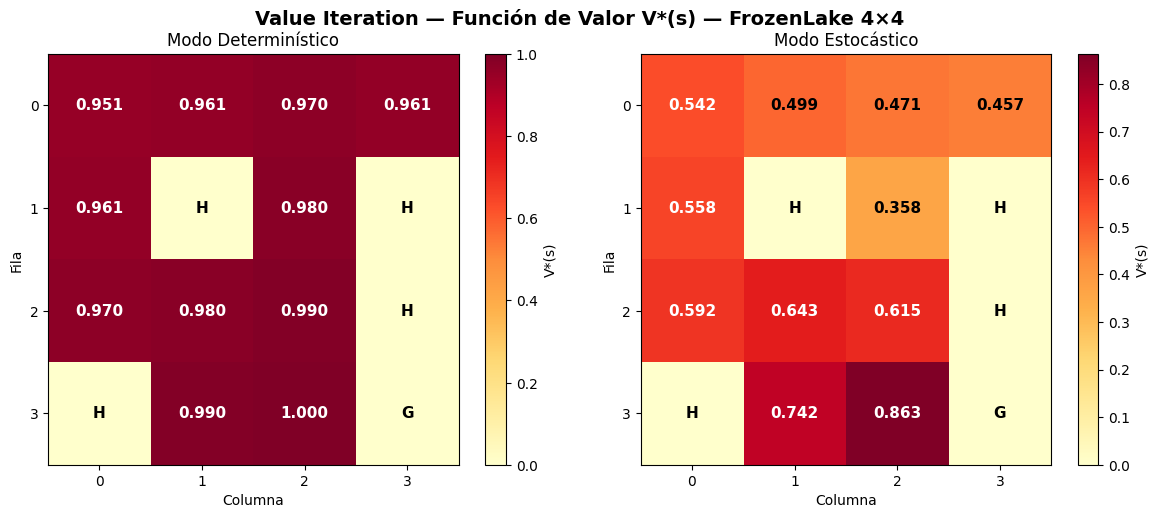

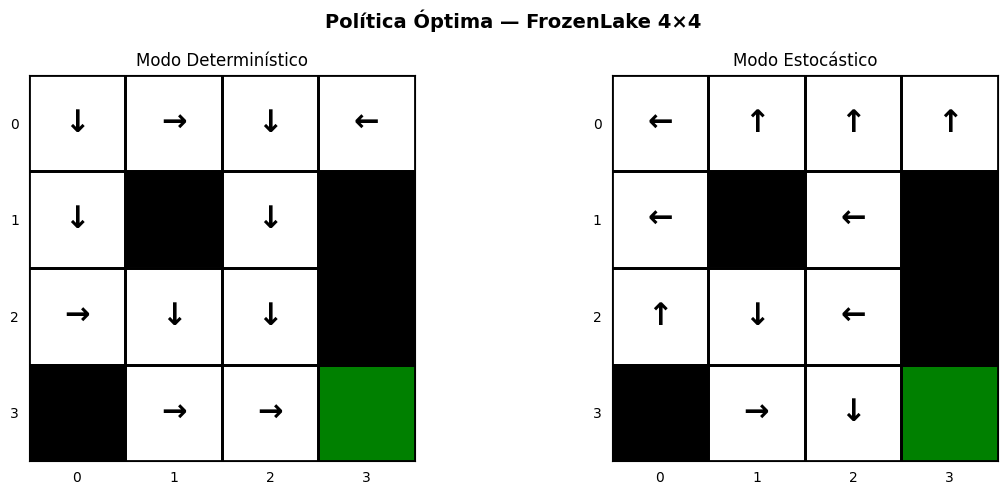



  TABLA COMPARATIVA DE CONFIGURACIONES
               Promedio  Desv. estándar  Tiempo promedio (s)
Configuración                                               
DETERMINISTA        1.0             0.0             0.000108
ESTOCÁSTICO         0.8             0.4             0.000547


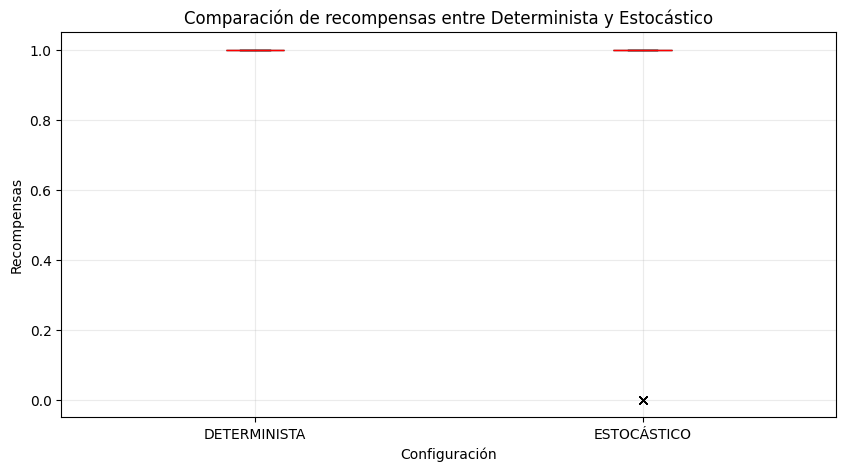

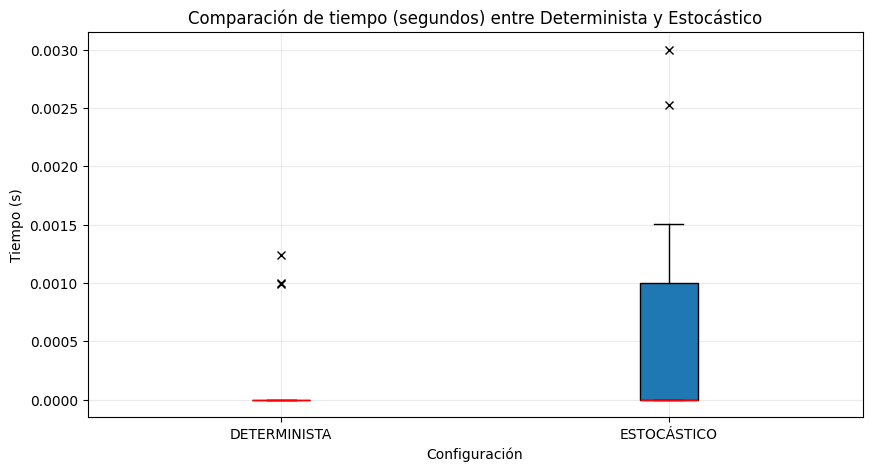

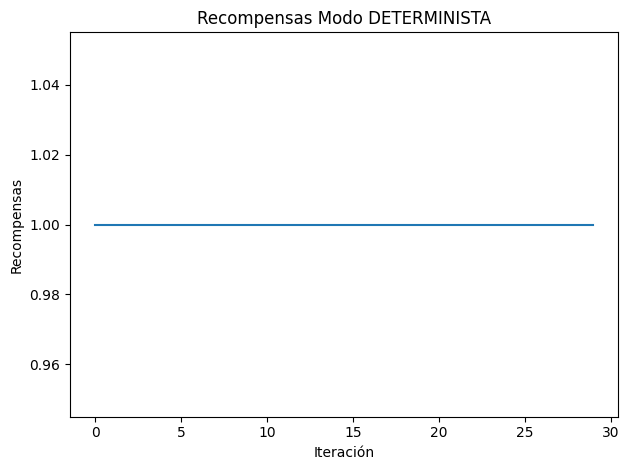

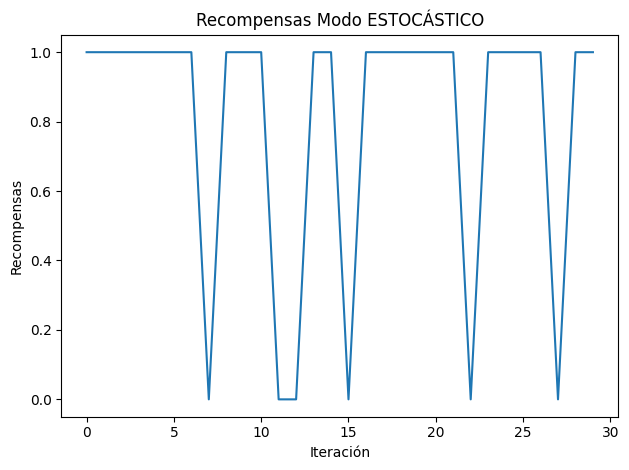

------------------------------------------------------------
       ANÁLISIS ESTADÍSTICO DE FITNESS
------------------------------------------------------------
Cantidad de grupos  : 2
Nivel de significancia (alfa): 0.05

------------------------------------------------------------
1. TEST DE NORMALIDAD (Kolmogorov-Smirnov)
------------------------------------------------------------

Regla de decision:
H0: todas las distribuciones son normales.
H1: al menos una distribucion no es normal.

DETERMINISTA -->  Estadístico = nan | p-valor = nan → NO NORMAL
ESTOCÁSTICO -->  Estadístico = 0.48849753 | p-valor = 0.00100000 → NO NORMAL


DECISION: Se rechaza H0, al menos una distribucion no es normal


------------------------------------------------------------
2. COMPARACIÓN ENTRE GRUPOS
------------------------------------------------------------

Se tienen 2 grupos → Test de Wilcoxon

Regla de decision:
H0: todas las distribuciones son iguales.
H1: al menos un par de grupos difiere.

Compa

c:\Users\leone\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\stats\_lilliefors.py:279: RuntimeWarning: invalid value encountered in divide
  z = (x - x.mean()) / x.std(ddof=1)


In [123]:
dimension = 4
resultados_generales = []

matriz_costos_v_determinista, politica_determinista, resultados_determinista = ejecutar_frozen_lake(False, dimension)
resultados_generales.append(resultados_determinista)
print("\n\n\n\n")

matriz_costos_v_estocastica, politica_estocastica, resultados_estocastica = ejecutar_frozen_lake(True, dimension)
resultados_generales.append(resultados_estocastica)
print("\n\n\n\n")

graficar_valor_iteration(matriz_costos_v_determinista, matriz_costos_v_estocastica, "value_iteration_4x4.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, matriz_costos_v_determinista, matriz_costos_v_estocastica,"politica_4x4.png", dimension)

tabla_comparativa(resultados_generales)
graficar_comparacion(resultados_generales)
graficar_solucion(resultados_generales)
analisis_estadistico_recompensas(resultados_generales)

FROZEN LAKE DETERMINISTA
POLITICA DETERMINISTA: 
 [1 0 1 0 1 0 1 0 2 1 1 0 0 2 2 0]


CUADRO DE PROBABILIDAD DE DECISIONES EN CADA BLOQUE
0 [0.56498649 0.95099005 0.14505569 0.57265217]
1 [0.46227279 0.         0.03309494 0.00299333]
2 [0.00107945 0.11355532 0.0002177  0.00318962]
3 [5.35041542e-03 0.00000000e+00 7.32550489e-06 8.98136700e-06]
4 [0.61307916 0.96059601 0.         0.50232309]
5 [0. 0. 0. 0.]
6 [0.         0.34438362 0.         0.00357469]
7 [0. 0. 0. 0.]
8 [0.5318846  0.         0.970299   0.60000062]
9 [0.61363621 0.9801     0.60430834 0.        ]
10 [0.14291358 0.93837357 0.         0.02739371]
11 [0. 0. 0. 0.]
12 [0. 0. 0. 0.]
13 [0.         0.71469686 0.99       0.5802067 ]
14 [0.62263271 0.70195554 1.         0.55568701]
15 [0. 0. 0. 0.]
FROZEN LAKE ESTOCÁSTICO
POLITICA ESTOCÁSTICO: 
 [1 3 1 0 1 0 0 0 1 1 1 0 0 1 1 0]


CUADRO DE PROBABILIDAD DE DECISIONES EN CADA BLOQUE
0 [0.02120936 0.06060769 0.02344786 0.02286849]
1 [0.00868497 0.00970473 0.01231555 0.06777588]


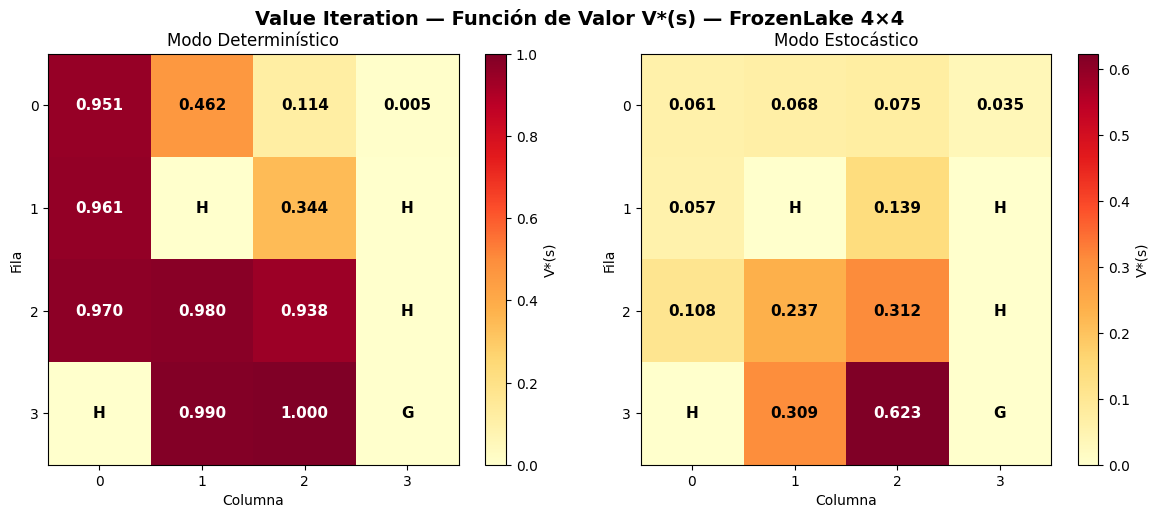

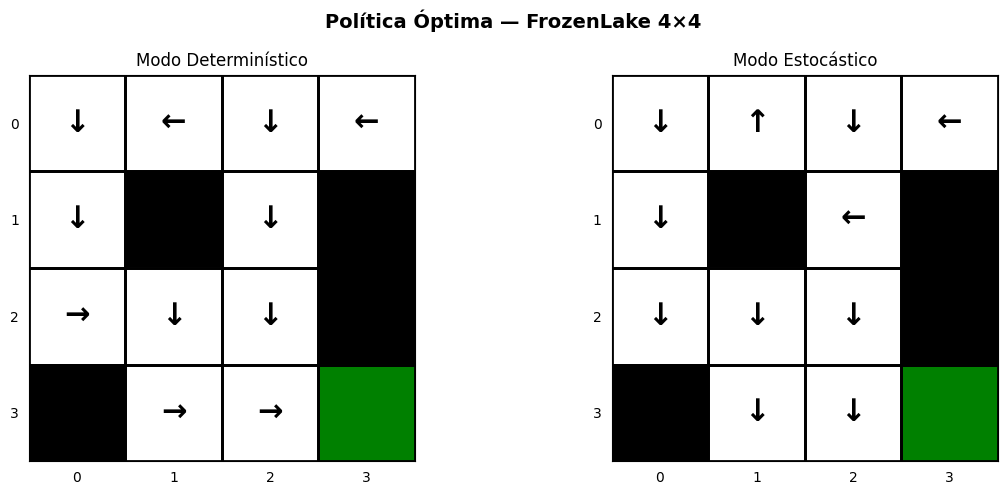

In [124]:
dimension = 4

def ejecutar_q_learning_frozen_lake(boolean_estocastico, dim):

    if boolean_estocastico: 
        tipo_frozen = "ESTOCÁSTICO" 
    else: 
        tipo_frozen = "DETERMINISTA"
    entorno = gym.make("FrozenLake-v1", is_slippery=boolean_estocastico)
    Q_obt, politica_a_devolver, recompensas = q_learning(
        entorno, es_continuo=False,
        alfa=0.01)

    print(f"FROZEN LAKE {tipo_frozen}")
    print(f"POLITICA {tipo_frozen}: \n",politica_a_devolver)
    print('\n')

    Q_a_devolver = np.zeros(dim*dim)
    print('CUADRO DE PROBABILIDAD DE DECISIONES EN CADA BLOQUE')
    for i,j in enumerate(Q_obt):
        print(f'{i}',j)
        Q_a_devolver[i] = max(j)
    
    return Q_a_devolver, politica_a_devolver, recompensas

Q_determinista, politica_determinista, recompensas_determinista = ejecutar_q_learning_frozen_lake(False, dimension)

Q_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_q_learning_frozen_lake(True, dimension)




graficar_valor_iteration(Q_determinista, Q_estocastica, f"q_value_{dimension}x{dimension}.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, Q_determinista, Q_estocastica,f"q_politica_{dimension}x{dimension}.png", dimension)

---

# Ejecución de Frozen Lake en un entorno 8x8.

FROZEN LAKE DETERMINISTA 8x8
Matriz DETERMINISTA de Valores:
[[0.8775 0.8864 0.8953 0.9044 0.9135 0.9227 0.9321 0.9415]
 [0.8864 0.8953 0.9044 0.9135 0.9227 0.9321 0.9415 0.951 ]
 [0.8953 0.9044 0.9135 0.     0.9321 0.9415 0.951  0.9606]
 [0.9044 0.9135 0.9227 0.9321 0.9415 0.     0.9606 0.9703]
 [0.8953 0.9044 0.9135 0.     0.951  0.9606 0.9703 0.9801]
 [0.8864 0.     0.     0.951  0.9606 0.9703 0.     0.99  ]
 [0.8953 0.     0.9321 0.9415 0.     0.9801 0.     1.    ]
 [0.9044 0.9135 0.9227 0.     0.9801 0.99   1.     0.    ]]

Política Óptima:
[['↓' '↓' '↓' '↓' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '→' '↓' '↓' '↓' '↓']
 ['↓' '↓' '↓' '←' '↓' '→' '↓' '↓']
 ['→' '→' '→' '→' '↓' '←' '↓' '↓']
 ['→' '→' '↑' '←' '↓' '↓' '→' '↓']
 ['↓' '←' '←' '→' '→' '↓' '←' '↓']
 ['↓' '←' '→' '↑' '←' '↓' '←' '↓']
 ['→' '→' '↑' '←' '→' '→' '→' '←']]

Porcentaje de exitos: 100.0000%





FROZEN LAKE ESTOCÁSTICO 8x8
Matriz ESTOCÁSTICO de Valores:
[[0.4146 0.4272 0.4461 0.4683 0.4924 0.5166 0.5353 0.541 ]
 [0.4117 0.

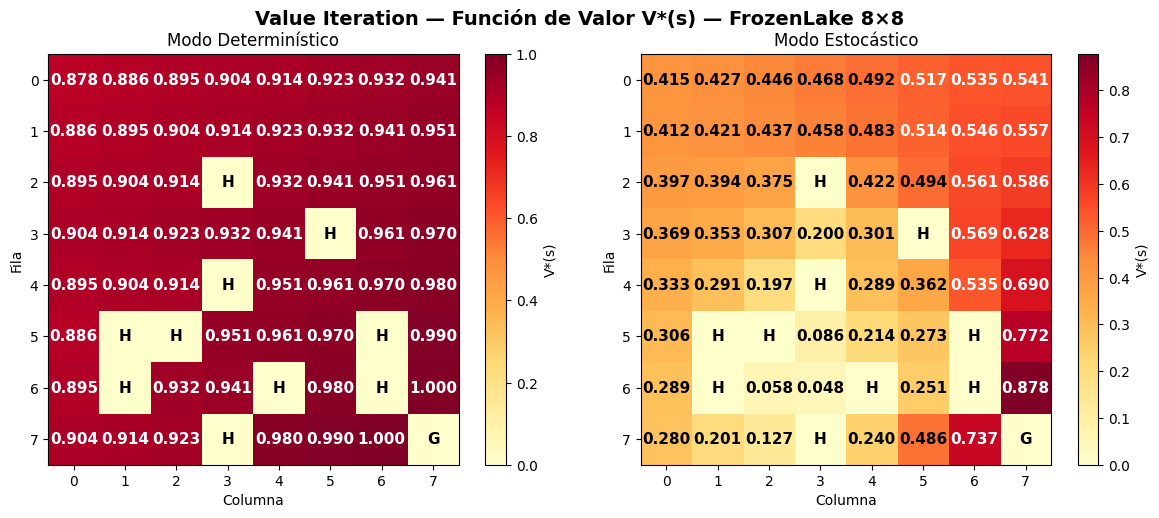

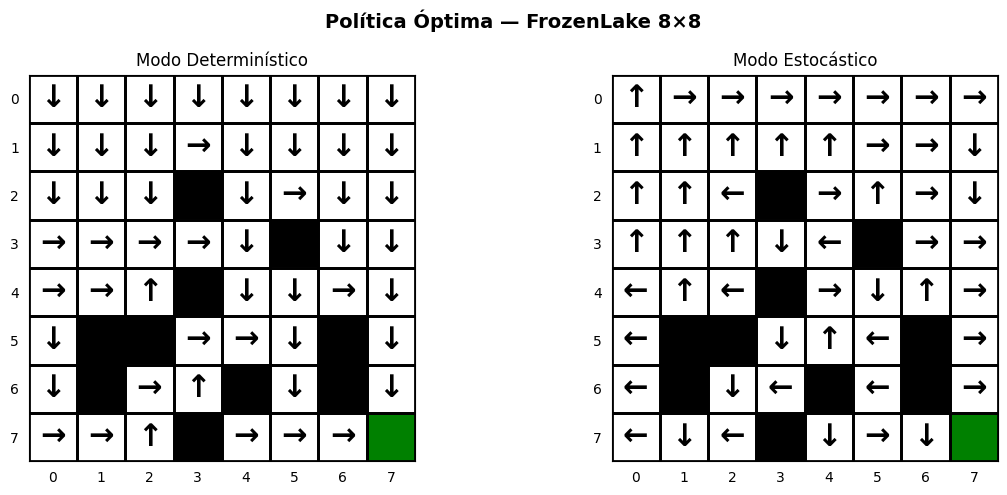

In [117]:
dimension = 8
matriz_costos_v_determinista, politica_determinista, recompensas_determinista = ejecutar_frozen_lake(False, dimension)

print("\n\n\n\n")
matriz_costos_v_estocastica, politica_estocastica, recompensas_estocastica = ejecutar_frozen_lake(True, dimension)

print("\n\n\n\n")
graficar_valor_iteration(matriz_costos_v_determinista, matriz_costos_v_estocastica, "value_iteration_8x8.png", dimension)
graficar_politica_frozen_lake(politica_determinista, politica_estocastica, matriz_costos_v_determinista, matriz_costos_v_estocastica,"politica_8x8.png", dimension)

---

# CART POLE

Es un entorno continuo, en el que un carro debe mantener en equilibrio un palo vertical. 

Para la resolucion aplicamos el algoritmo q-learning, pero para poder hacerlo necesitamos discretizar el entorno, para esto decidimos hacerlo en 11 estados posibles, para cada una de sus variables continuas.


In [160]:
# ponemos los valores maximos y minimos para los parametros sin limites
low=np.array([-4.8, -3.5, -0.418, -3.5])
high=np.array([ 4.8,  3.5,  0.418,  3.5])
entorno_cartPole = gym.make("CartPole-v1", sutton_barto_reward=True)
Q_cartPole, politica_cartPole, recompensas_cartPole = q_learning(entorno_cartPole, es_continuo=True,low=low,high=high,k=11,devolver_pasos=True)


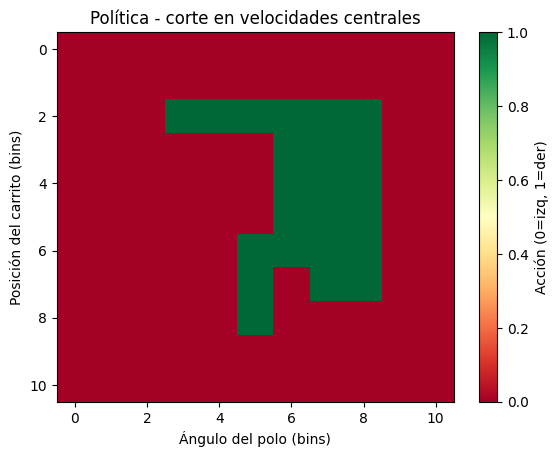

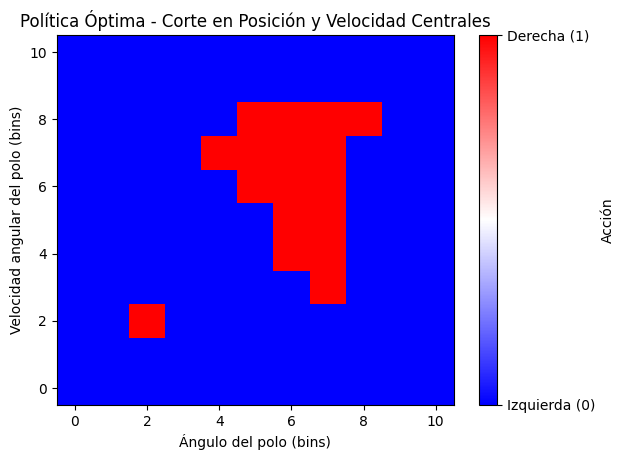

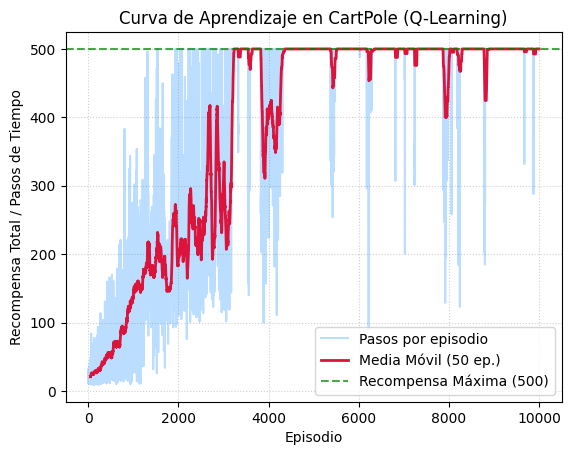

In [ ]:
# graficos
plt.imshow(politica_cartPole[:, 5, :, 5], cmap='RdYlGn', aspect='auto')
plt.xlabel("Ángulo del polo (bins)")
plt.ylabel("Posición del carrito (bins)")
plt.title("Política - corte en velocidades centrales")
plt.colorbar(label="Acción (0=izq, 1=der)")
plt.show()

politica_corte = politica_cartPole[5, 5, :, :]

# Usamos origin='lower' para que los valores negativos/bajos queden abajo en el eje Y
plt.imshow(politica_corte, cmap='bwr', aspect='auto', origin='lower')

# Ajustamos las etiquetas de los ejes según las nuevas variables
plt.xlabel("Ángulo del polo (bins)")
plt.ylabel("Velocidad angular del polo (bins)")
plt.title("Política Óptima - Corte en Posición y Velocidad Centrales")

# Configuramos la barra de colores para que sea discreta (0 o 1)
cbar = plt.colorbar(ticks=[0, 1])
cbar.set_label("Acción")
cbar.ax.set_yticklabels(['Izquierda (0)', 'Derecha (1)'])

plt.show()


window = 50
moving_avg = np.convolve(recompensas_cartPole, np.ones(window)/window, mode='valid')

num_episodios = len(recompensas_cartPole)

plt.plot(range(num_episodios), recompensas_cartPole, alpha=0.3, color='dodgerblue', label='Pasos por episodio')
plt.plot(range(window-1, num_episodios), moving_avg, color='crimson', linewidth=2, label=f'Media Móvil ({window} ep.)')

plt.axhline(y=500, color='green', linestyle='--', alpha=0.7, label='Recompensa Máxima (500)')
plt.title('Curva de Aprendizaje en CartPole (Q-Learning)')
plt.xlabel('Episodio')
plt.ylabel('Recompensa Total / Pasos de Tiempo')
plt.legend(loc='lower right')
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('cartpole_learning_curve.png', bbox_inches='tight')
plt.show()

In [169]:
# pruebas con la politica aprendida 

env = gym.make ("CartPole-v1" )
recompensas = []
completado=0
repeticiones = 2000

for _ in range(repeticiones):
    obs, _ = env.reset()
    estado = discretizar(obs, low=low, high=high, k=11)
    terminado = False
    r = 0
    while not terminado:
        accion = politica_cartPole[estado]
        obs, recompensa, fin, trunc, _ = env.step(accion)
        terminado = fin or trunc
        estado = discretizar(obs, low=low, high=high, k=11)
        r += recompensa
    recompensas.append(r)
    if r == 500:
        completado +=1

print(f"Media: {np.mean(recompensas):.1f} | Desviacion: {np.std(recompensas):.1f} | Min: {min(recompensas)} | Max: {max(recompensas)} | Completados:{completado}/{repeticiones}")

Media: 500.0 | Desviacion: 0.0 | Min: 500.0 | Max: 500.0 | Completados:2000/2000


In [166]:
# ejecucion visual del agente con la politica aprendida

env_visual = gym.make("CartPole-v1", render_mode="human",max_episode_steps=500) 
observacion, info = env_visual.reset()

estado = discretizar(observacion,low=low,high=high,k=11,)
terminado = False
recompensa_prueba = 0

iteracion = 0
while not terminado and iteracion < 500:
    # time.sleep(0.03) #esto es para que la simulacion dure un poquito mas
    accion = politica_cartPole[estado] 
    

    siguiente_observacion, recompensa, finalizado, truncado, _ = env_visual.step(accion)
    terminado = finalizado or truncado
    recompensa_prueba += recompensa
    

    estado = discretizar(siguiente_observacion,low=low,high=high,k=11)
print(f"Recompensa obtenida en la prueba visual: {recompensa_prueba}")
env_visual.close()

Recompensa obtenida en la prueba visual: 500.0
